# InCommodities Case Crunch 2026 - Kaggle Dataset EDA
This notebook structurally validates the newly provided unified pipeline feature datasets (`x_train.csv`, `y_train.csv`). It integrates causal forward-filling for sparse daily variables (like regional gas prices and emissions) directly relying on the configurations established in `config.yaml`.

In [8]:
import sys
import os
from pathlib import Path

# Ensure the /src/ modules are importable globally
sys.path.append(os.path.abspath('..'))

from src.data_ingestion import load_competition_data
from sklearn.feature_selection import mutual_info_regression
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Ingestion Pipeline & Imputation
Mechanically pulling the dataset utilizing the `load_competition_data()` wrapper to seamlessly merge, index, and properly execute the causal `ffill` on sparse market variables.

In [9]:
print("Loading competition dataset via pipeline ingestion wrapper...")
df = load_competition_data(config_path="../config.yaml")

print(f"Working shape of merged dataset: {df.shape}")
print(f"Total NaN count across all columns: {df.isna().sum().sum()}")

Loading competition dataset via pipeline ingestion wrapper...
Working shape of merged dataset: (17544, 110)
Total NaN count across all columns: 132843


### 2. Multi-Information (MI) Regression
Evaluating target variance utilizing Mutual Information against all individual temporal lags and indices to select the strict top-30 parameters. 

**Note:** To prevent data destruction, we perform a temporary median imputation strictly for the MI calculation, as `mutual_info_regression` requires a dense matrix.

In [10]:
targets = ['fr_spot', 'uk_spot']
features = [c for c in df.columns if c not in targets]

# 1. Temporary imputation JUST for Mutual Information calculation
print("Performing temporary median imputation for MI calculation (preventing data destruction)...")
X_mi = df[features].fillna(df[features].median())

# Establish outputs directories
out_dir = Path("../data/outputs")
out_dir.mkdir(parents=True, exist_ok=True)

top_features_by_target = {}

for target in targets:
    print("="*60)
    print(f"Executing Mutual Information Regression globally against: {target}")
    print("="*60)
    
    # Match target rows with dense feature matrix (X_mi)
    y = df[target]
    
    # MI regression still needs dense target; if target itself has NaNs, we must drop those specific rows
    mask = y.notna()
    mi_scores = mutual_info_regression(X_mi[mask], y[mask], random_state=42)
    
    mi_series = pd.Series(mi_scores, index=features).sort_values(ascending=False)
    top_30 = mi_series.head(30)
    top_features_by_target[target] = top_30.index.tolist()
    
    print(f"\nTop 30 Most Impactful Features for [{target}]:")
    print(top_30)
    print("\n")

Performing temporary median imputation for MI calculation (preventing data destruction)...
Executing Mutual Information Regression globally against: fr_spot

Top 30 Most Impactful Features for [fr_spot]:
fr_spot_la                           1.002731
ch_spot_la                           0.927986
de_gas                               0.884248
nl_gas                               0.867622
fr_gas                               0.861205
be_spot_la                           0.859390
at_spot_la                           0.859097
es_gas                               0.839654
uk_gas                               0.803762
uk_emission                          0.788783
uk_spot_la                           0.767701
nl_spot_la                           0.763476
de_spot_la                           0.724017
atc_fr-uk-3_f                        0.698196
fr_nuclear_avcap_f                   0.696349
atc_uk-fr-3_f                        0.693546
fr_gas_avcap_f                       0.682670
atc_uk-fr-1_f 

### 3. Multicollinearity Execution (Spearman Rank Correlation)
Plotting the pairwise Spearman Rank Correlation among those precise top-30 variables. 

**Note:** We use the original `df` here because `pandas.corr` natively handles pairwise completeness (skipping NaNs only for the specific pair being calculated), allowing us to use the full chronological record.

Generating Spearman Correlation Heatmap for top 30 fr_spot predictors...
-> Successfully saved visualization to: ..\data\outputs\spearman_heatmap_fr_spot.png



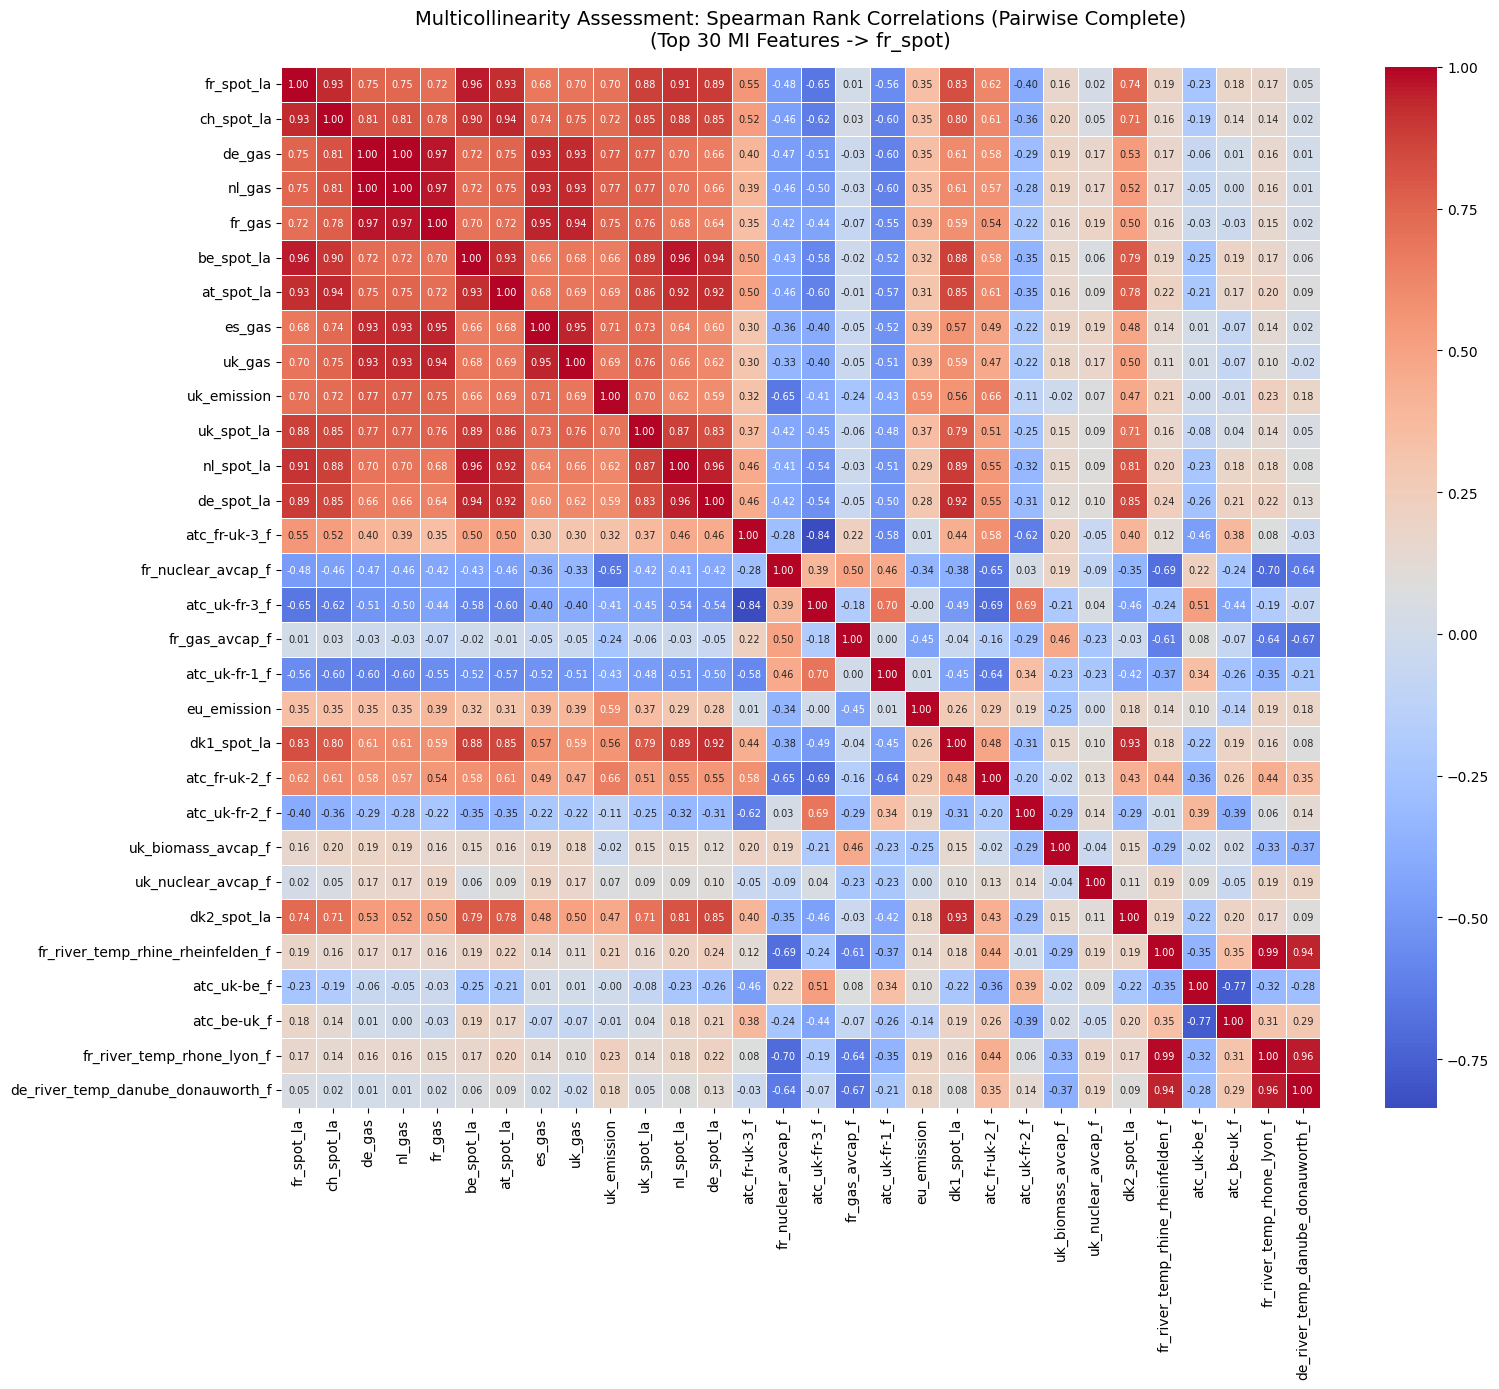

Generating Spearman Correlation Heatmap for top 30 uk_spot predictors...
-> Successfully saved visualization to: ..\data\outputs\spearman_heatmap_uk_spot.png



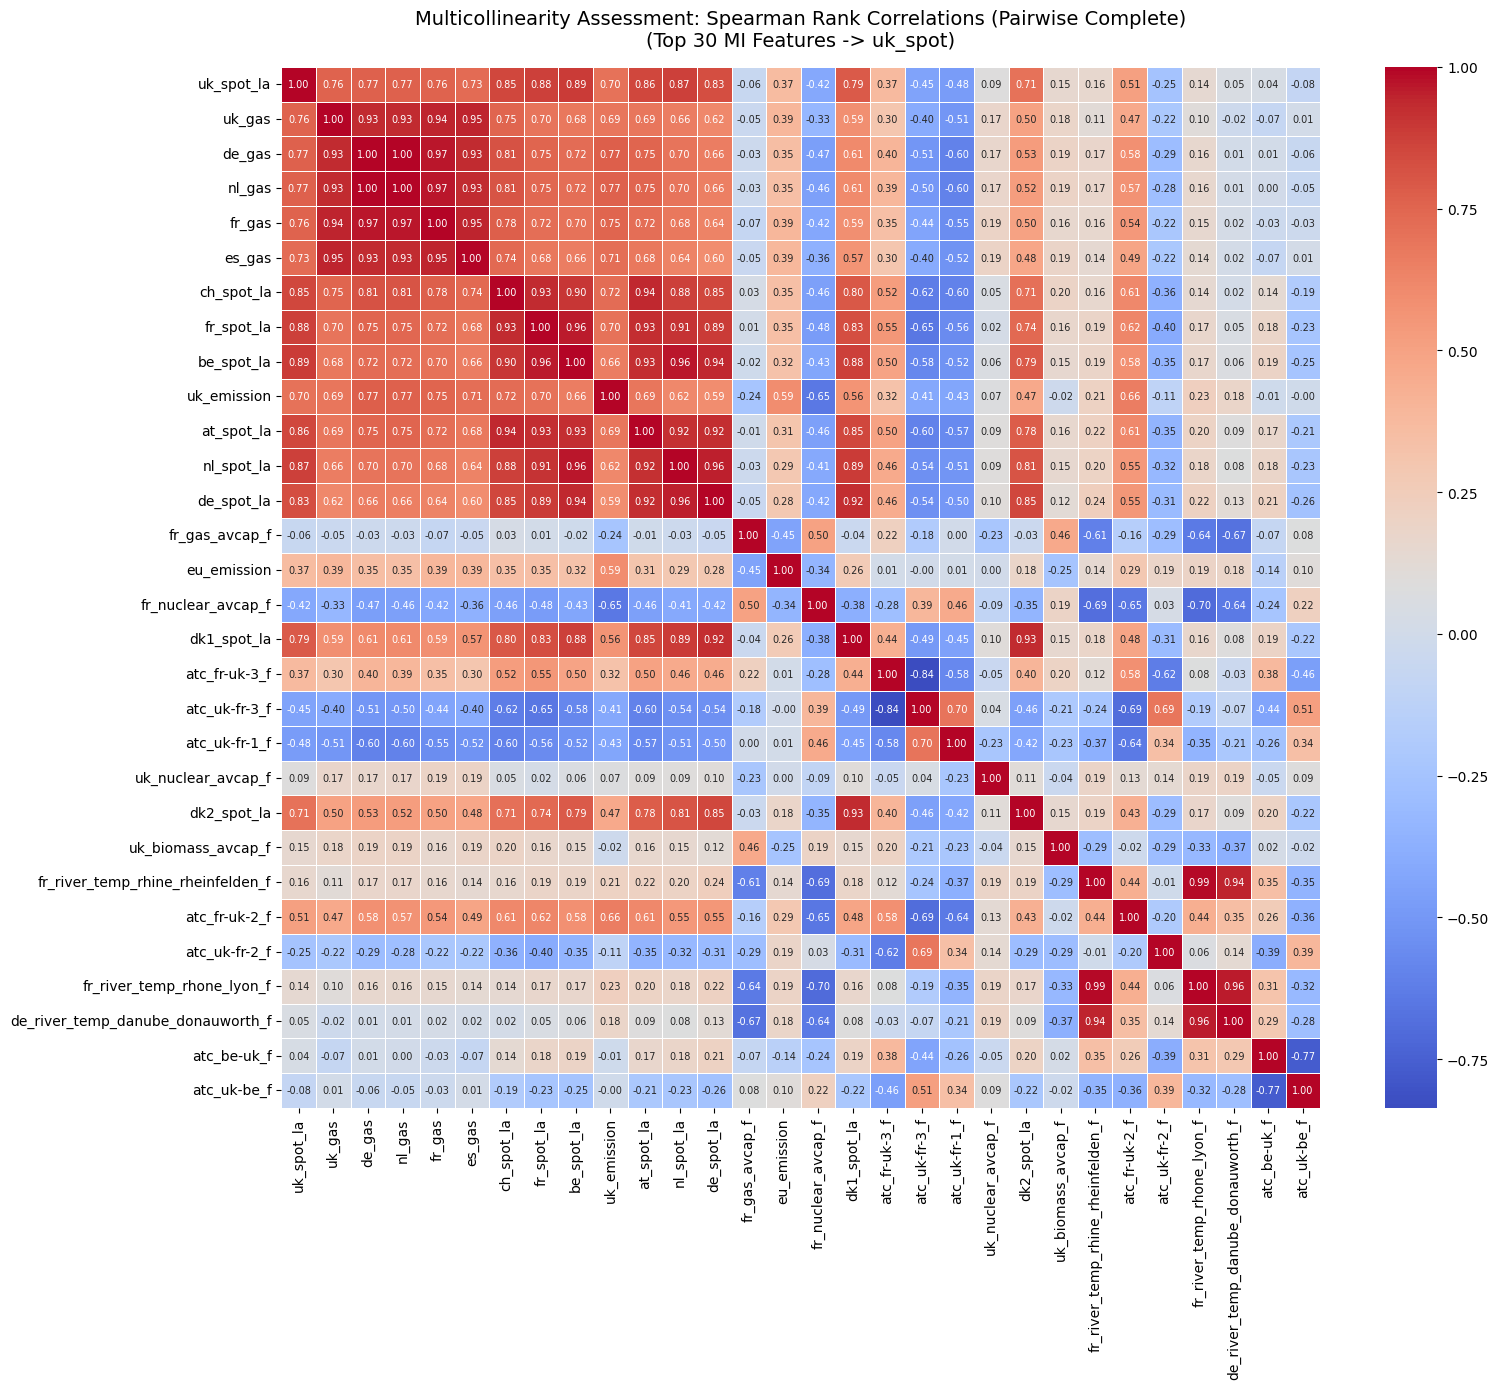

In [11]:
for target in targets:
    print(f"Generating Spearman Correlation Heatmap for top 30 {target} predictors...")
    top_30_features = top_features_by_target[target]
    
    # Use original df for pairwise Spearman completeness
    spearman_corr = df[top_30_features].corr(method='spearman')
    
    plt.figure(figsize=(16, 14))
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, annot_kws={'size': 7})
    plt.title(f'Multicollinearity Assessment: Spearman Rank Correlations (Pairwise Complete)\n(Top 30 MI Features -> {target})', fontsize=14, pad=15)
    plt.tight_layout()
    
    save_path = out_dir / f"spearman_heatmap_{target}.png"
    plt.savefig(save_path)
    print(f"-> Successfully saved visualization to: {save_path}\n")
    plt.show()

### 4. Target Distribution & Extremes
Analyzing higher-order moments and frequency of non-positive prices to inform loss function selection (Huber vs MAE) and identify potential floor-pricing dynamics.

In [12]:
for target in targets:
    y = df[target].dropna()
    stats = {
        'Mean': y.mean(),
        'StdDev': y.std(),
        'Skewness': y.skew(),
        'Kurtosis': y.kurtosis()
    }
    neg_count = (y <= 0).sum()
    neg_pct = (neg_count / len(y)) * 100
    
    print("="*60)
    print(f"Target Diagnostics: {target}")
    print("="*60)
    for k, v in stats.items():
        print(f"{k:10}: {v:.4f}")
    print(f"Hours <= 0 : {neg_count} ({neg_pct:.2f}%)")
    print("\n")

Target Diagnostics: fr_spot
Mean      : 140.9506
StdDev    : 141.6205
Skewness  : 1.9338
Kurtosis  : 3.6895
Hours <= 0 : 549 (3.13%)


Target Diagnostics: uk_spot
Mean      : 140.8286
StdDev    : 113.1010
Skewness  : 2.6294
Kurtosis  : 11.3062
Hours <= 0 : 237 (1.35%)




### 5. Fill-Rate Audit (Causal Verification)
Verifying that the forward-fill (ffill) logic in `src/data_ingestion.py` has correctly propagated daily values through the hourly index.

In [13]:
audit_cols = ['de_gas', 'eu_emission']
atc_cols = [c for c in df.columns if 'atc_' in c]
final_audit = audit_cols + atc_cols

print("Remaining NaNs Audit:")
print("-"*30)
nan_counts = df[final_audit].isna().sum()
print(nan_counts[nan_counts > 0] if not nan_counts.empty else "No NaNs in audit columns.")
print(f"\nFull Audit Results:\n{nan_counts}")

Remaining NaNs Audit:
------------------------------
atc_dk1-uk_f     12937
atc_fr-uk-3_f       48
atc_nl-uk_f      10728
atc_uk-dk1_f     12937
atc_uk-fr-3_f       48
atc_uk-nl_f      10728
dtype: int64

Full Audit Results:
de_gas               0
eu_emission          0
atc_be-uk_f          0
atc_dk1-uk_f     12937
atc_fr-uk-1_f        0
atc_fr-uk-2_f        0
atc_fr-uk-3_f       48
atc_nl-uk_f      10728
atc_uk-be_f          0
atc_uk-dk1_f     12937
atc_uk-fr-1_f        0
atc_uk-fr-2_f        0
atc_uk-fr-3_f       48
atc_uk-nl_f      10728
dtype: int64
